In [130]:
#Import Pandas and pyplot
import pandas as pd
import matplotlib.pyplot as plt

In [248]:
#import dataset and preview

df = pd.read_csv(r'mtn_churn.csv')
df.sample(5)


,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
792,CUST0404,Maryam Buck,Feb-25,72,Osun,5G Broadband Router,Female,2,Fair,19,30GB Monthly Broadband Plan,9000,16,144000,199.75,No,NaN
683,CUST0349,Michael Smith,Jan-25,50,Kogi,Broadband MiFi,Female,5,Excellent,3,60GB Monthly Broadband Plan,14500,3,43500,192.37,No,NaN
712,CUST0361,Obinna Andrews,Feb-25,58,Kebbi,Mobile SIM Card,Male,4,Very Good,33,7GB Monthly Plan,3500,13,45500,136.53,No,NaN
660,CUST0336,Chinedu Reynolds,Mar-25,58,Sokoto,Mobile SIM Card,Male,1,Poor,7,16.5GB+10mins Monthly Plan,6500,15,97500,64.17,No,NaN
903,CUST0463,Grace Bell,Feb-25,74,Borno,4G Router,Male,4,Very Good,45,65GB Monthly Plan,16000,14,224000,120.52,No,NaN


In [250]:
df.head(1)

,Customer_ID,Full_Name,Date_of_Purchase,Age,State,MTN_Device,Gender,Satisfaction_Rate,Customer_Review,Customer_Tenure_in_months,Subscription_Plan,Unit_Price,Number_of_Times_Purchased,Total_Revenue,Data_Usage,Customer_Churn_Status,Reasons_for_Churn
0,CUST0001,Ngozi Berry,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation


In [253]:
#Replace space in column names with underscore
# new_columns = []
# for names in df.columns:
#     new_col = names.replace(' ', '_')
#     new_columns.append(new_col)
# df.columns = new_columns

df.columns = df.columns.str.replace(' ', '_')


In [255]:
df.columns = df.columns.str.lower()

In [256]:
df["customer_churn_status"] = df["customer_churn_status"].str.lower().str.strip()
df["gender"] = df["gender"].str.lower().str.strip()

In [257]:
df.sample(1)

,customer_id,full_name,date_of_purchase,age,state,mtn_device,gender,satisfaction_rate,customer_review,customer_tenure_in_months,subscription_plan,unit_price,number_of_times_purchased,total_revenue,data_usage,customer_churn_status,reasons_for_churn
396,CUST0203,Ibim Castro,Feb-25,45,Oyo,Mobile SIM Card,female,5,Excellent,53,16.5GB+10mins Monthly Plan,6500,17,110500,114.46,no,NaN


In [196]:
#COUNT DISTINCT CUSTOMERS
df['customer_id'].nunique()


496

In [258]:
churn = df.groupby('customer_churn_status')['customer_id'].nunique().reset_index(name='count')
churn


,customer_churn_status,count
0,no,350
1,yes,146


Text(0.5, 1.0, 'Customer churn')

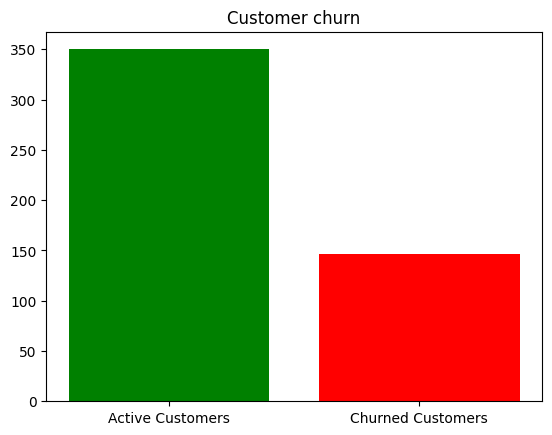

In [138]:
plt.bar(churn['customer_churn_status'], churn['count'], color=["green","red"]) 
plt.xticks([1, 0], ["Churned Customers", "Active Customers"])
plt.title('Customer churn')

In [ ]:
#Get churn rate
summary = df.groupby("customer_churn_status")["customer_id"].nunique()

churn_rate = 100 * summary["yes"] / summary.sum()
print(f'{churn_rate:,.2f}')

29.44


In [274]:
genders = df.groupby('gender')['customer_id'].nunique().reset_index(name='count')


Text(0.5, 1.0, 'Gender Distribution')

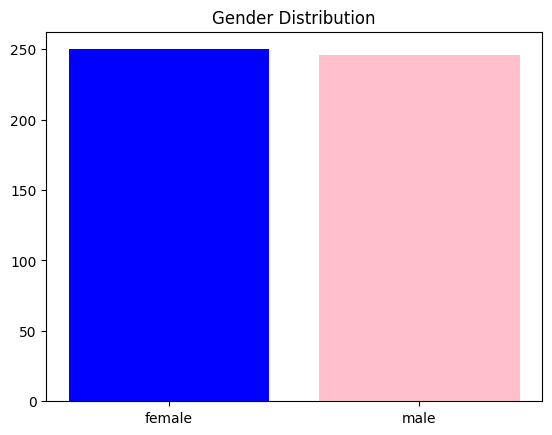

In [281]:
plt.bar(genders['gender'], genders['count'], color=['blue', 'pink'])
plt.title('Gender Distribution')

In [302]:

churn_calc = df[df['customer_churn_status'] == 'yes'].groupby('gender')['customer_id'].nunique().reset_index(name='churn')
churn_calc

,gender,churn
0,female,77
1,male,69


In [359]:
total = df.customer_id.nunique()
men = df[df['gender'] == 'male']['customer_id'].nunique()
women = df[df['gender'] == 'female']['customer_id'].nunique()
churn_men = df[(df['customer_churn_status'] == 'yes') & (df['gender'] == 'male')]['customer_id'].nunique()
female_churn = df[(df['customer_churn_status'] == 'yes') & (df['gender'] == 'female')]['customer_id'].nunique()

In [360]:
print(f'Total:{total}, men: {men}, women: {women}, churn_men: {churn_men}, female_churn: {female_churn}')

Total:496, men: 246, women: 250, churn_men: 69, female_churn: 77


In [361]:
(100 * churn_men) / total

13.911290322580646

In [324]:
df[df['customer_churn_status'] == 'yes']

,customer_id,full_name,date_of_purchase,age,state,mtn_device,gender,satisfaction_rate,customer_review,customer_tenure_in_months,subscription_plan,unit_price,number_of_times_purchased,total_revenue,data_usage,customer_churn_status,reasons_for_churn
0,CUST0001,Ngozi Berry,Jan-25,27,Kwara,4G Router,male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,yes,Relocation
1,CUST0002,Zainab Baker,Mar-25,16,Abuja (FCT),Mobile SIM Card,female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,yes,Better Offers from Competitors
10,CUST0007,Boma Stewart,Mar-25,24,Jigawa,Broadband MiFi,female,5,Excellent,39,120GB Monthly Broadband Plan,24000,11,264000,150.30,yes,Relocation
16,CUST0011,Ejiro Griffith,Feb-25,72,Bauchi,4G Router,female,2,Fair,8,65GB Monthly Plan,16000,2,32000,14.66,yes,Poor Network
17,CUST0011,Ejiro Griffith,Feb-25,72,Bauchi,5G Broadband Router,female,2,Fair,8,60GB Monthly Broadband Plan,14500,2,29000,13.95,yes,Poor Network
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,CUST0496,Grace Matthews,Jan-25,76,Akwa Ibom,4G Router,female,2,Fair,41,10GB+10mins Monthly Plan,4500,13,58500,61.55,yes,Poor Customer Service
964,CUST0496,Grace Matthews,Jan-25,76,Akwa Ibom,Mobile SIM Card,female,2,Fair,41,1.5GB 2-Day Plan,600,12,7200,187.13,yes,Poor Customer Service
971,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,4G Router,male,4,Very Good,31,165GB Monthly Plan,35000,15,525000,144.64,yes,High Call Tarriffs
972,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,Mobile SIM Card,male,4,Very Good,31,7GB Monthly Plan,3500,11,38500,158.49,yes,High Call Tarriffs
